In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
actual = pd.read_json("../public/data/actual.json")
forecast = pd.read_json("../public/data/forecast.json")

actual.head()

,startTime,generation
0,2024-01-01T00:00:00Z,8500
1,2024-01-01T01:00:00Z,8700
2,2024-01-01T02:00:00Z,9100
3,2024-01-01T03:00:00Z,9400
4,2024-01-01T04:00:00Z,9600


In [4]:
actual["startTime"] = pd.to_datetime(actual["startTime"])

forecast["startTime"] = pd.to_datetime(forecast["startTime"])
forecast["publishTime"] = pd.to_datetime(forecast["publishTime"])

In [5]:
merged = pd.merge(
    actual,
    forecast,
    on="startTime",
    how="left"
)

merged.head()

,startTime,generation_x,publishTime,generation_y
0,2024-01-01 00:00:00+00:00,8500,2023-12-31 20:00:00+00:00,8300.0
1,2024-01-01 00:00:00+00:00,8500,2023-12-31 22:00:00+00:00,8400.0
2,2024-01-01 01:00:00+00:00,8700,2023-12-31 21:00:00+00:00,8600.0
3,2024-01-01 01:00:00+00:00,8700,2023-12-31 23:00:00+00:00,8800.0
4,2024-01-01 02:00:00+00:00,9100,2023-12-31 23:00:00+00:00,9000.0


In [6]:
merged["error"] = merged["generation_x"] - merged["generation_y"]

merged.head()

,startTime,generation_x,publishTime,generation_y,error
0,2024-01-01 00:00:00+00:00,8500,2023-12-31 20:00:00+00:00,8300.0,200.0
1,2024-01-01 00:00:00+00:00,8500,2023-12-31 22:00:00+00:00,8400.0,100.0
2,2024-01-01 01:00:00+00:00,8700,2023-12-31 21:00:00+00:00,8600.0,100.0
3,2024-01-01 01:00:00+00:00,8700,2023-12-31 23:00:00+00:00,8800.0,-100.0
4,2024-01-01 02:00:00+00:00,9100,2023-12-31 23:00:00+00:00,9000.0,100.0


In [7]:
mean_error = merged["error"].mean()
median_error = merged["error"].median()
p99_error = merged["error"].quantile(0.99)

print("Mean Error:", mean_error)
print("Median Error:", median_error)
print("P99 Error:", p99_error)

Mean Error: 100.0
Median Error: 100.0
P99 Error: 200.0


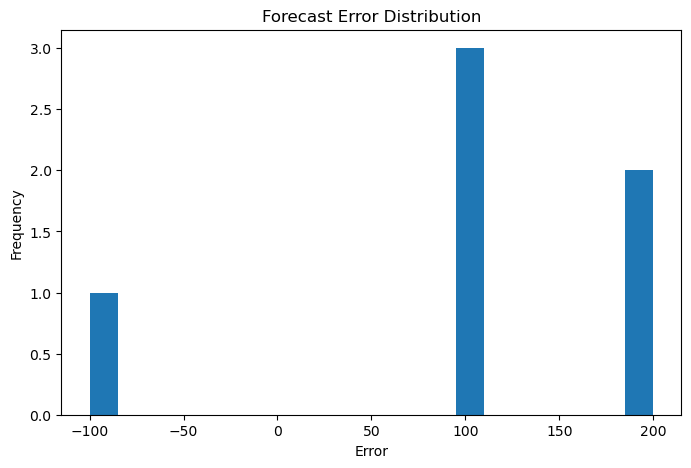

In [8]:
plt.figure(figsize=(8,5))

plt.hist(merged["error"], bins=20)

plt.title("Forecast Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.show()

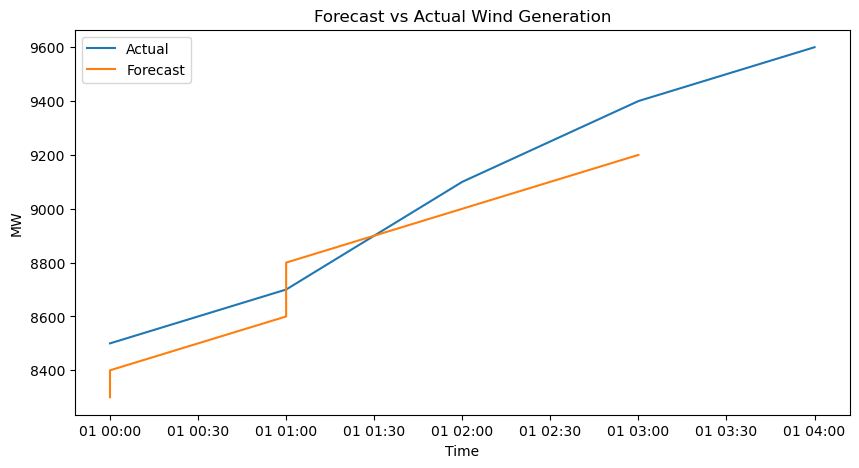

In [9]:
plt.figure(figsize=(10,5))

plt.plot(merged["startTime"], merged["generation_x"], label="Actual")
plt.plot(merged["startTime"], merged["generation_y"], label="Forecast")

plt.legend()

plt.title("Forecast vs Actual Wind Generation")

plt.xlabel("Time")
plt.ylabel("MW")

plt.show()

In [10]:
reliable_capacity = actual["generation"].quantile(0.05)

print("Reliable Wind Capacity:", reliable_capacity)

Reliable Wind Capacity: 8540.0
